In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

load data

In [2]:
# load X_train data file
X_train_df = pd.read_csv('../data/raw/X_train_update.csv', index_col=0)
display(X_train_df.head(5))
print(f"shape X_train_df: {X_train_df.shape}\n")
print(X_train_df.info(),"\n")
print(f"null values X_train_df:\n{X_train_df.isna().sum()}\n")

,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786


shape X_train_df: (84916, 4)

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 3.2+ MB
None 

null values X_train_df:
designation        0
description    29800
productid          0
imageid            0
dtype: int64



In [3]:
# load class codes file
df_classes = pd.read_csv('../data/raw/Y_train_CVw08PX.csv', index_col=0)
display(df_classes.head(5))
print(f"shape df_classes: {df_classes.shape}\n")
print(df_classes.info(),"\n")
print(f"null values df_classes:\n{df_classes.isna().sum()}\n")

,prdtypecode
0,10
1,2280
2,50
3,1280
4,2705


shape df_classes: (84916, 1)

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prdtypecode  84916 non-null  int64
dtypes: int64(1)
memory usage: 1.3 MB
None 

null values df_classes:
prdtypecode    0
dtype: int64



In [4]:
# merge classes code and labels
classe_label = pd.read_csv("../data/raw/product_class.csv", sep=';')
display(classe_label.head(5))
print(f"shape df_classes_label: {classe_label.shape}\n")
print(classe_label.info(),"\n")
print(f"null values df_classes_label:\n{classe_label.isna().sum()}\n")

,target,prdtypecode,prodtype
0,0,10,Livres adultes
1,24,40,Jeux vidéo import
2,25,50,Accessoires jeux vidéo
3,26,60,Jeux et consoles rétro
4,1,1140,Goodies geek


shape df_classes_label: (27, 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   target       27 non-null     int64 
 1   prdtypecode  27 non-null     int64 
 2   prodtype     27 non-null     object
dtypes: int64(2), object(1)
memory usage: 780.0+ bytes
None 

null values df_classes_label:
target         0
prdtypecode    0
prodtype       0
dtype: int64



In [5]:
# merge class codes & labels
df_prdt_type = df_classes.merge(classe_label, left_on='prdtypecode', right_on='prdtypecode', how='left')
display(df_prdt_type.head(5))
print(f"shape df_prdt_type: {df_prdt_type.shape}\n")
print(df_prdt_type.info(),"\n")
print(f"null values df_prdt_type:\n{df_prdt_type.isna().sum()}\n")


,prdtypecode,target,prodtype
0,10,0,Livres adultes
1,2280,15,Magazines
2,50,25,Accessoires jeux vidéo
3,1280,4,Jouets enfance
4,2705,22,Livres illustrés


shape df_prdt_type: (84916, 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   prdtypecode  84916 non-null  int64 
 1   target       84916 non-null  int64 
 2   prodtype     84916 non-null  object
dtypes: int64(2), object(1)
memory usage: 1.9+ MB
None 

null values df_prdt_type:
prdtypecode    0
target         0
prodtype       0
dtype: int64



### merge train data & prdt_type

In [6]:
df_merge = X_train_df.merge(df_prdt_type, left_index=True, right_index=True, how='left')
display(df_merge.head(5))
print(f"shape df_merge: {df_merge.shape}\n")
print(df_merge.info(),"\n")
print(f"null values df_merge:\n{df_merge.isna().sum()}\n")

,designation,description,productid,imageid,prdtypecode,target,prodtype
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10,0,Livres adultes
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280,15,Magazines
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50,25,Accessoires jeux vidéo
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280,4,Jouets enfance
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705,22,Livres illustrés


shape df_merge: (84916, 7)

<class 'pandas.core.frame.DataFrame'>
Index: 84916 entries, 0 to 84915
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
 4   prdtypecode  84916 non-null  int64 
 5   target       84916 non-null  int64 
 6   prodtype     84916 non-null  object
dtypes: int64(4), object(3)
memory usage: 5.2+ MB
None 

null values df_merge:
designation        0
description    29800
productid          0
imageid            0
prdtypecode        0
target             0
prodtype           0
dtype: int64



### load train images

Number of training images: 84916


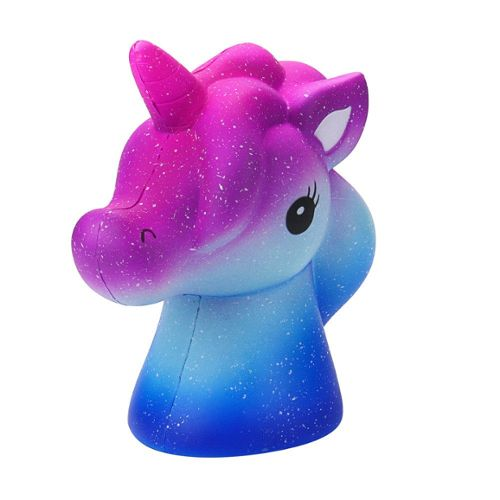

Sample image size: (500, 500)


In [7]:
# load train images
import os
from PIL import Image

image_dir = '../data/raw/images/image_train/'
image_files = os.listdir(image_dir)
print(f"Number of training images: {len(image_files)}")

# Load and display a sample image
sample_image_path = os.path.join(image_dir, image_files[0])
sample_image = Image.open(sample_image_path)
display(sample_image)
print(f"Sample image size: {sample_image.size}")

In [8]:
# df with image paths
import re


images = []
image_dir = '../data/raw/images/image_train/'
for filename in os.listdir(image_dir):
    img = m = re.match(r"image_(\d+)_product_(\d+)\.jpg", filename)
    if filename.endswith('.jpg') :
        image_id = int(re.findall(r'(\d+)', filename)[0])
        product_id = int(re.findall(r'(\d+)', filename)[1])
        path_image = os.path.join(image_dir, filename)
        images.append({'imageid': image_id, 'productid': product_id, 'filename': filename, 'path_image': path_image})

df_images = pd.DataFrame(images)
display(df_images.head(5))
print(f"shape df_images: {df_images.shape}\n")
print(df_images.info(),"\n")
print(f"null values df_images:\n{df_images.isna().sum()}\n")


,imageid,productid,filename,path_image
0,1257676811,3881724430,image_1257676811_product_3881724430.jpg,../data/raw/images/image_train/image_125767681...
1,933237064,190092802,image_933237064_product_190092802.jpg,../data/raw/images/image_train/image_933237064...
2,1203644850,2034468031,image_1203644850_product_2034468031.jpg,../data/raw/images/image_train/image_120364485...
3,1104740515,1842319046,image_1104740515_product_1842319046.jpg,../data/raw/images/image_train/image_110474051...
4,1025427045,551792608,image_1025427045_product_551792608.jpg,../data/raw/images/image_train/image_102542704...


shape df_images: (84916, 4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   imageid     84916 non-null  int64 
 1   productid   84916 non-null  int64 
 2   filename    84916 non-null  object
 3   path_image  84916 non-null  object
dtypes: int64(2), object(2)
memory usage: 2.6+ MB
None 

null values df_images:
imageid       0
productid     0
filename      0
path_image    0
dtype: int64



### final merge text + images

In [17]:
# final merge text + images
df_temp = df_merge.merge(df_images, left_on=['productid','imageid'], right_on=['productid','imageid'], how='left')

df_temp = df_temp.drop(columns=['filename','target'])
display(df_temp.head(5))
print(f"shape df_temp: {df_temp.shape}\n")
print(df_temp.info(),"\n")
print(f"null values df_temp:\n{df_temp.isna().sum()}\n")

,designation,description,productid,imageid,prdtypecode,prodtype,path_image
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10,Livres adultes,../data/raw/images/image_train/image_126359704...
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280,Magazines,../data/raw/images/image_train/image_100814123...
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50,Accessoires jeux vidéo,../data/raw/images/image_train/image_938777978...
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280,Jouets enfance,../data/raw/images/image_train/image_457047496...
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705,Livres illustrés,../data/raw/images/image_train/image_107775778...


shape df_temp: (84916, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   designation  84916 non-null  object
 1   description  55116 non-null  object
 2   productid    84916 non-null  int64 
 3   imageid      84916 non-null  int64 
 4   prdtypecode  84916 non-null  int64 
 5   prodtype     84916 non-null  object
 6   path_image   84916 non-null  object
dtypes: int64(3), object(4)
memory usage: 4.5+ MB
None 

null values df_temp:
designation        0
description    29800
productid          0
imageid            0
prdtypecode        0
prodtype           0
path_image         0
dtype: int64



The *designation* is always available and provides essential information, while the *description* may occasionally be missing.
To maximize text quality, we systematically combine the title with the description whenever it exists.

This **conditional concatenation** produces richer and more informative text, while keeping the input consistent even when the description is missing. It provides the model with **more contextual information**, improves the quality of the text embeddings, and helps the classifier better distinguish similar categories.

In practice, the text embedding is built as follows:

```
text = designation + " " + description  

```

This strategy ensures optimal use of all available information, regardless of completeness.

### Clean Text

In [ ]:
# suppress URLs and HTML tags & normalize text
import re
import html

def clean_text(text: str) -> str:
    
    """
    Nettoie et normalise une chaîne de caractères pour l'analyse NLP.
    
    Étapes :
    - Unescape HTML & minuscules
    - Suppression : Balises HTML, URLs, Emails
    - Suppression spécifique : Codes produits (SKU, EAN, Ref...), références alphanumériques
    - Suppression : Nombres longs (>6 chiffres) et espaces superflus
    """
    
    if text is None or pd.isna(text):
        return ""
    text = html.unescape(str(text)).lower()

    # supprimer HTML
    text = re.sub(r"<[^>]+>", " ", text)

    # supprimer URLs + emails 
    text = re.sub(r"http[s]?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " ", text)

    # supprimer codes produits
    text = re.sub(
        r"\b(ref|réf|reference|référence|fabricant|model|modèle|sku|asin|ean|isbn|gtin)[\s\.:_-]*[a-z0-9][a-z0-9\-_.]{2,}\b",
        " ",
        text
    )
    text = re.sub(r"[a-zA-Z]{2,}-\d+(?:-[a-zA-Z]{2,})?", " ", text)

    # supprimer nombres longs
    text = re.sub(r"\b\d{6,}\b", " ", text)
     
    # nettoyage final
    text = re.sub(r"\s+", " ", text).strip()

    return text


df_temp['product_designation'] = df_temp['designation'].apply(clean_text)
df_temp['product_description'] = df_temp['description'].apply(clean_text)

In [19]:
df_temp.head(10)

,designation,description,productid,imageid,prdtypecode,prodtype,path_image,product_designation,product_description
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10,Livres adultes,../data/raw/images/image_train/image_126359704...,olivia: personalisiertes notizbuch / 150 seite...,
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280,Magazines,../data/raw/images/image_train/image_100814123...,journal des arts (le) n° 133 du 28/09/2001 - l...,
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50,Accessoires jeux vidéo,../data/raw/images/image_train/image_938777978...,grand stylet ergonomique bleu gamepad nintendo...,pilot style touch pen de marque speedlink est ...
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280,Jouets enfance,../data/raw/images/image_train/image_457047496...,peluche donald - europe - disneyland 2000 (mar...,
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705,Livres illustrés,../data/raw/images/image_train/image_107775778...,la guerre des tuques,luc a des idées de grandeur. il veut organiser...
5,Afrique Contemporaine N° 212 Hiver 2004 - Doss...,NaN,5862738,393356830,2280,Magazines,../data/raw/images/image_train/image_393356830...,afrique contemporaine n° 212 hiver 2004 - doss...,
6,Christof E: Bildungsprozessen Auf Der Spur,NaN,91920807,907794536,10,Livres adultes,../data/raw/images/image_train/image_907794536...,christof e: bildungsprozessen auf der spur,
7,Conquérant Sept Cahier Couverture Polypro 240 ...,CONQUERANT CLASSIQUE Cahier 240 x 320 mm seyès...,344240059,999581347,2522,Papeterie,../data/raw/images/image_train/image_999581347...,conquérant sept cahier couverture polypro 240 ...,conquerant classique cahier 240 x 320 mm seyès...
8,Puzzle Scooby-Doo Avec Poster 2x35 Pieces,NaN,4239126071,1325918866,1280,Jouets enfance,../data/raw/images/image_train/image_132591886...,puzzle scooby-doo avec poster 2x35 pieces,
9,Tente Pliante V3s5-Pro Pvc Blanc - 3 X 4m50 - ...,Tente pliante V3S5 Pro PVC 500 gr/m² - 3 x 4m5...,3793572222,1245644185,2582,Mobilier de jardin & cuisine,../data/raw/images/image_train/image_124564418...,tente pliante v3s5-pro pvc blanc - 3 x 4m50 - ...,tente pliante v3s5 pro pvc 500 gr/m² - 3 x 4m5...


In [20]:
df_final = df_temp.drop(columns=['designation','description'], inplace=False)

In [21]:
df_final.head(10)

,productid,imageid,prdtypecode,prodtype,path_image,product_designation,product_description
0,3804725264,1263597046,10,Livres adultes,../data/raw/images/image_train/image_126359704...,olivia: personalisiertes notizbuch / 150 seite...,
1,436067568,1008141237,2280,Magazines,../data/raw/images/image_train/image_100814123...,journal des arts (le) n° 133 du 28/09/2001 - l...,
2,201115110,938777978,50,Accessoires jeux vidéo,../data/raw/images/image_train/image_938777978...,grand stylet ergonomique bleu gamepad nintendo...,pilot style touch pen de marque speedlink est ...
3,50418756,457047496,1280,Jouets enfance,../data/raw/images/image_train/image_457047496...,peluche donald - europe - disneyland 2000 (mar...,
4,278535884,1077757786,2705,Livres illustrés,../data/raw/images/image_train/image_107775778...,la guerre des tuques,luc a des idées de grandeur. il veut organiser...
5,5862738,393356830,2280,Magazines,../data/raw/images/image_train/image_393356830...,afrique contemporaine n° 212 hiver 2004 - doss...,
6,91920807,907794536,10,Livres adultes,../data/raw/images/image_train/image_907794536...,christof e: bildungsprozessen auf der spur,
7,344240059,999581347,2522,Papeterie,../data/raw/images/image_train/image_999581347...,conquérant sept cahier couverture polypro 240 ...,conquerant classique cahier 240 x 320 mm seyès...
8,4239126071,1325918866,1280,Jouets enfance,../data/raw/images/image_train/image_132591886...,puzzle scooby-doo avec poster 2x35 pieces,
9,3793572222,1245644185,2582,Mobilier de jardin & cuisine,../data/raw/images/image_train/image_124564418...,tente pliante v3s5-pro pvc blanc - 3 x 4m50 - ...,tente pliante v3s5 pro pvc 500 gr/m² - 3 x 4m5...


### Data distribution

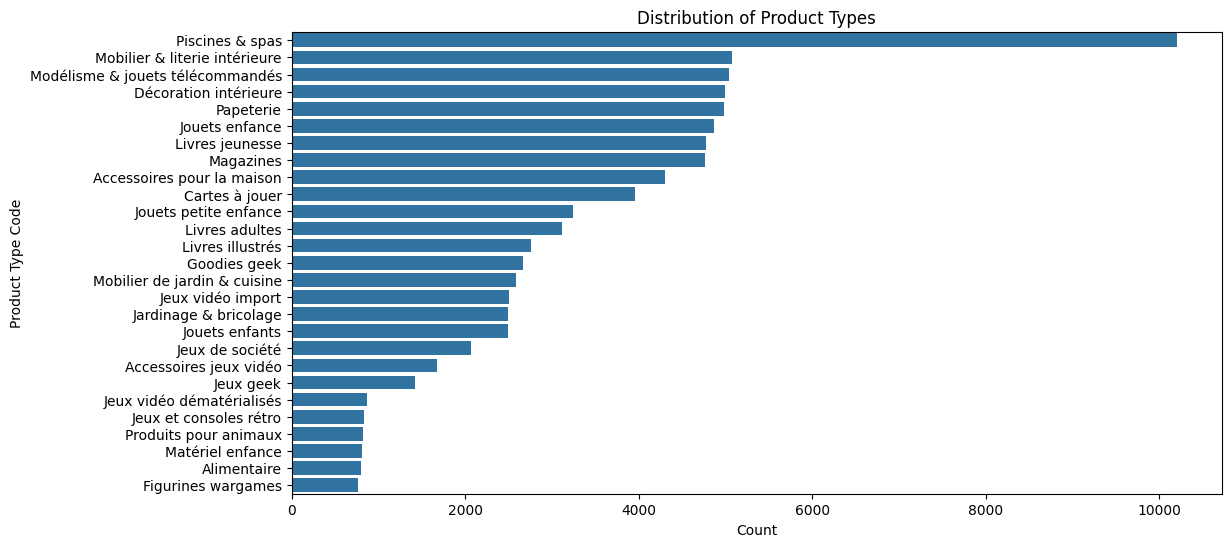

In [ ]:
# product type distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(data=df_final, y='prodtype', order=df_final['prodtype'].value_counts().index)
plt.title('Distribution of Product Types')
plt.xlabel('Count')
plt.ylabel('Product Type Code')
plt.show()

The dataset shows a **significant class imbalance**, with some categories (e.g., *Piscines & spas*, *Mobilier & literie intérieure*) heavily over-represented, while others (*Figurines wargames*, *Alimentaire*, *Matériel enfance*) contain far fewer samples.

This imbalance has three key implications:

1. **Bias in Learning**
   The model tends to favor majority classes, achieving good overall accuracy but struggling with **rare categories**.

2. **Higher Classification Difficulty**
   Minority classes are harder to model, leading to weaker representation and more classification errors.

3. **Need for Dedicated Mitigation**
   To reduce imbalance effects, the pipeline uses:

   * stratified data splits,
   * inverse class-frequency weighting,
